In [6]:
import h5torch
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
celltype_folder = "/data/home/natant/Negatives/Data/Encode690/ENCODE_hg38_subset_101bp_celltypes_ATAC_H5_all_chr"

In [8]:
h5t_files = [os.path.join(celltype_folder,f) for f in os.listdir(celltype_folder) if f.endswith('.h5t') and f.replace('.h5t', '') in ['HepG2', 'K562', 'GM12878', 'A549']]


In [9]:
h5t_files


['/data/home/natant/Negatives/Data/Encode690/ENCODE_hg38_subset_101bp_celltypes_ATAC_H5_all_chr/GM12878.h5t',
 '/data/home/natant/Negatives/Data/Encode690/ENCODE_hg38_subset_101bp_celltypes_ATAC_H5_all_chr/HepG2.h5t',
 '/data/home/natant/Negatives/Data/Encode690/ENCODE_hg38_subset_101bp_celltypes_ATAC_H5_all_chr/K562.h5t',
 '/data/home/natant/Negatives/Data/Encode690/ENCODE_hg38_subset_101bp_celltypes_ATAC_H5_all_chr/A549.h5t']

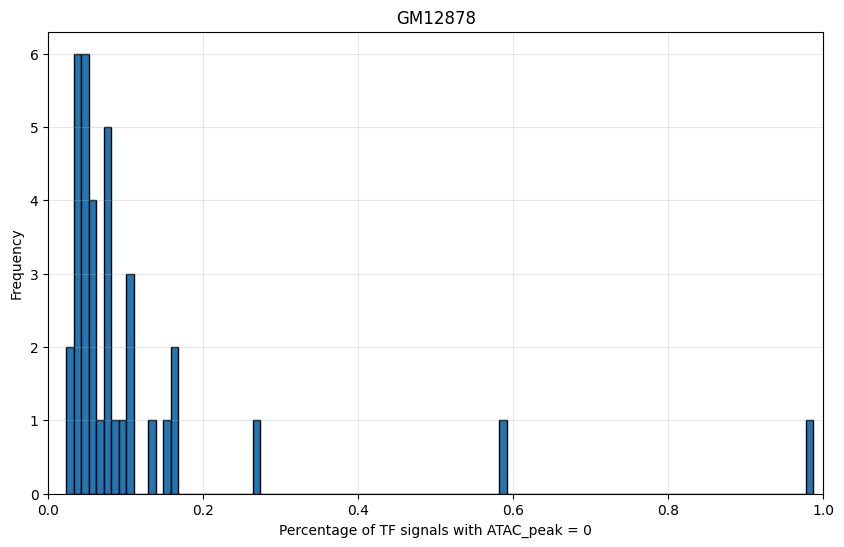

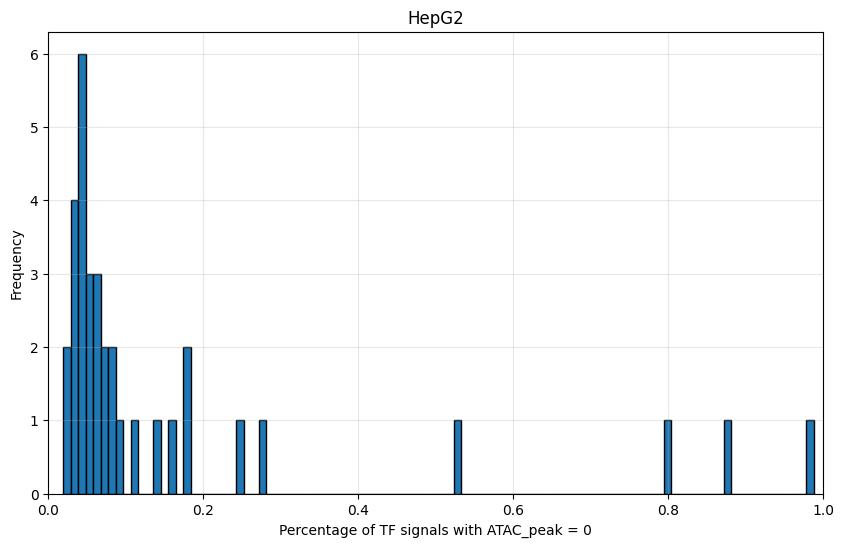

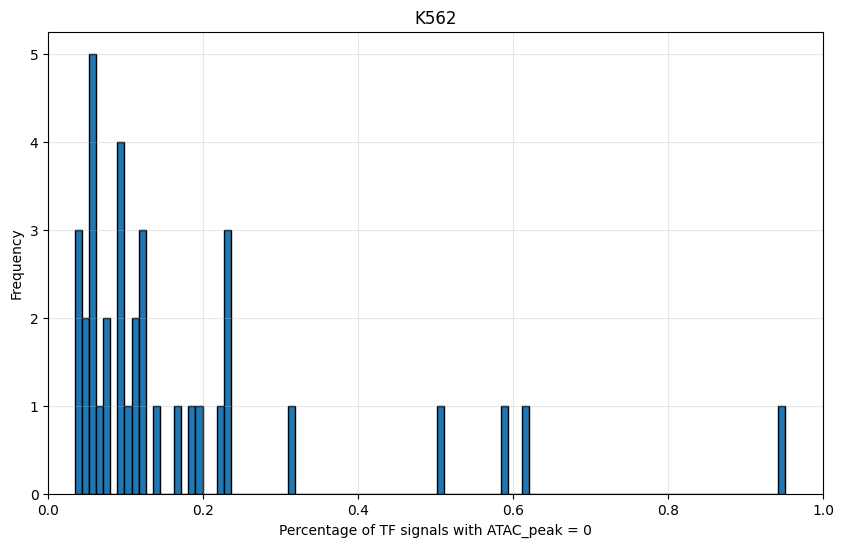

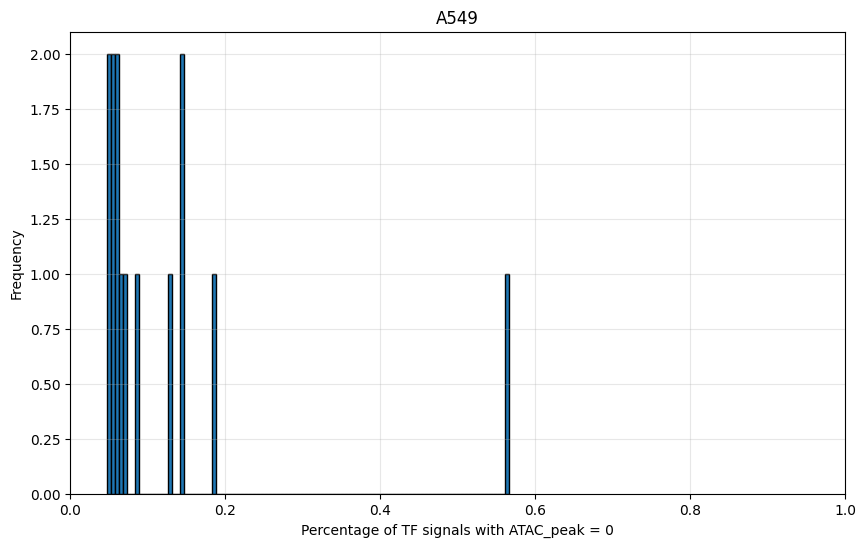

In [10]:
for cell_file in h5t_files:
    file = h5torch.File(cell_file, 'r')
    central = file["central"][:]
    prot_names = file["0/prot_names"][:]
    # Count how many times each TF has a 1 while ATAC_peak is 0
    atac_index = prot_names.tolist().index(b'ATAC_peak')
    atac_peak = central[atac_index]
    results = {}
    results_percentage = {}

    for i in range(len(prot_names)):
        if i == atac_index:
            continue
        tf_name = prot_names[i].decode('utf-8')
        tf_signal = central[i]
        
        # Count positions where TF is 1 and ATAC_peak is 0
        count = np.sum((tf_signal == 1) & (atac_peak == 0))
        results[tf_name] = count
        results_percentage[tf_name] = count / (tf_signal==1).sum()


    # Get the cell line name from the file
    cell_line = os.path.basename(cell_file).replace('.h5t', '')

    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(list(results_percentage.values()), bins=100, edgecolor='black')
    plt.xlabel('Percentage of TF signals with ATAC_peak = 0')
    plt.ylabel('Frequency')
    plt.title(f'{cell_line}')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.show()



In [11]:
import pickle

with open("/data/home/natant/Negatives/testing_ground/20250613_NUMBER_OF_POSITIVES_PER_GROUP.pkl", "rb") as f:
    number_of_positives = pickle.load(f)
# Convert the nested dictionary 'number_of_positives' into a pandas DataFrame
number_of_positives_df = (
    pd.DataFrame([
        {"celltype": ct, "TF": tf, "positives 1": vals[0], "positives 2": vals[1], "positives 3": vals[2]}
        for ct, tf_dict in number_of_positives.items()
        for tf, vals in tf_dict.items()
    ])
)
number_of_positives_df

,celltype,TF,positives 1,positives 2,positives 3
0,MCF-7,CTCF,7124,5733,8144
1,MCF-7,TCF7L2,2909,2949,4439
2,MCF-7,ZNF217,2911,2775,4259
3,MCF-7,GATA3_(SC-268),1853,1606,2624
4,GM12878,CTCF,12222,12053,15832
...,...,...,...,...,...
127,A549,USF-1,2170,2457,3821
128,A549,ETS1,1535,1503,2503
129,A549,SIX5,1488,1318,2109
130,A549,ZBTB33,1896,2039,3222


In [12]:
number_of_positives_df["celltype"].unique()

array(['MCF-7', 'GM12878', 'HepG2', 'IMR90', 'HCT-116', 'PANC-1', 'K562',
       'HEK293', 'A549'], dtype=object)

In [54]:
df_summaries = {}
# Create a summary table for each cell line
for cell_file in h5t_files:
    file = h5torch.File(cell_file, 'r')
    central = file["central"][:]
    prot_names = file["0/prot_names"][:]
    
    # Get ATAC_peak index and data
    atac_index = prot_names.tolist().index(b'ATAC_peak')
    atac_peak = central[atac_index]
    
    # Get the cell line name from the file
    cell_line = os.path.basename(cell_file).replace('.h5t', '')
    
    # Prepare data for the table
    table_data = []
    
    for i in range(len(prot_names)):
        if i == atac_index:
            continue
        
        tf_name = prot_names[i].decode('utf-8')
        tf_signal = central[i]


        new_vector = np.full(atac_peak.shape, 2)
        new_vector[(tf_signal == 1)] = 1
        new_vector[(atac_peak == 1) & (tf_signal != 2)] = 0
        OG_pos = (new_vector==1).sum()
        OG_neg = (new_vector==0).sum()

        new_vector = np.full(atac_peak.shape, 2)
        new_vector[(atac_peak == 1) & (tf_signal != 2)] = 0
        new_vector[(tf_signal == 1)] = 1
        new_pos = (new_vector==1).sum()
        new_neg = (new_vector==0).sum()
        overlap = new_vector[(atac_peak == 1) & (tf_signal == 1)].sum()
        overlap_2 = new_vector[(atac_peak == 2) & (tf_signal == 1)].sum()


        
        # Number of positives (TF == 1)
        num_positives = np.sum(tf_signal == 1)
        
        # Number of positives that overlap with ATAC_peak = 0
        num_overlap_atac_0 = np.sum((tf_signal == 1) & (atac_peak == 0))
        
        # Percentage
        percentage = (num_overlap_atac_0 / num_positives) if num_positives > 0 else 0
        
        # Number of negatives (TF == 0)

        num_negatives = np.sum(tf_signal == 0)
        
        # Number of masked (TF == 2)
        num_masked = np.sum(tf_signal == 2)

        pos_split_1 = number_of_positives_df[(number_of_positives_df['celltype'] == cell_line) & (number_of_positives_df['TF'] == tf_name)]['positives 1'].values[0]
        pos_split_2 = number_of_positives_df[(number_of_positives_df['celltype'] == cell_line) & (number_of_positives_df['TF'] == tf_name)]['positives 2'].values[0]
        pos_split_3 = number_of_positives_df[(number_of_positives_df['celltype'] == cell_line) & (number_of_positives_df['TF'] == tf_name)]['positives 3'].values[0]
        
        table_data.append({
            'TF': tf_name,
            "Positives": pos_split_1 + pos_split_2 + pos_split_3,
            'Pos Split 1': pos_split_1,
            'Pos Split 2': pos_split_2,
            'Pos Split 3': pos_split_3,
            
            'Negatives': num_negatives,
            "Positives (\%)": (pos_split_1 + pos_split_2 + pos_split_3)/(pos_split_1 + pos_split_2 + pos_split_3 + num_negatives) * 100,
            #"Pos/Neg Ratio": f'{((pos_split_1+pos_split_2+pos_split_3) / num_negatives):.2f}' if num_negatives > 0 else 'Inf',
            #'Overlap_ATAC=0': num_overlap_atac_0,
            'Pos in closed ATAC (\%)': f'{percentage*100:.2f}',
            #'Masked': num_masked,
            # 'OG Positives': OG_pos,
            # 'OG Negatives': OG_neg,
            # 'New Positives': new_pos,
            # 'New Negatives': new_neg,
            # 'Overlap Pos & ATAC=1': overlap,
            # "Overlap Pos & ATAC=2": overlap_2,
            # "missing": num_positives - (overlap + overlap_2+ num_overlap_atac_0)
        })
        df_summaries[cell_line] = pd.DataFrame(table_data)
        df_summaries[cell_line] = df_summaries[cell_line][df_summaries[cell_line]["Positives"] > 1000]
        df_summaries[cell_line]["TF"] = df_summaries[cell_line]["TF"].str.replace("_", r"\_", regex=False)
    

In [55]:
for cell_line, df_summary in df_summaries.items():
    # sort by total Positives descending
    df_sorted = df_summary.sort_values("Positives", ascending=False)

    # Export to LaTeX
    latex_output = df_sorted.to_latex(
        index=False,
        caption=f'{cell_line} Summary Statistics',
        label=f'tab:{cell_line.lower()}'
    )

    # Save to file
    with open(f'{cell_line}_summary.tex', 'w') as f:
        f.write(latex_output)

    print(f"Exported LaTeX table for {cell_line} to {cell_line}_summary.tex")

    print(f"\n{'='*80}")
    print(f"Cell Line: {cell_line}")
    print(f"{'='*80}")
    print(df_sorted.to_string(index=False))
    print()

Exported LaTeX table for GM12878 to GM12878_summary.tex

Cell Line: GM12878
                  TF  Positives  Pos Split 1  Pos Split 2  Pos Split 3  Negatives  Positives (\%) Pos in closed ATAC (\%)
                CTCF      40107        12222        12053        15832     664845        5.689324                    9.38
       YY1\_(SC-281)      30998         8978         9385        12635     616168        4.789807                    7.41
    NFIC\_(SC-81335)      29066         8488         8008        12570     633948        4.383919                    7.60
    ATF2\_(SC-81188)      23490         6856         6427        10207     639389        3.543633                    5.09
      ELF1\_(SC-631)      22998         6649         7101         9248     640654        3.465370                    5.99
     FOXM1\_(SC-502)      22935         6564         6456         9915     630437        3.510251                    4.18
               TCF12      20437         5777         6163         8497

In [48]:
cellline_stats_df.n_TFs.sum()

np.int64(115)